In [89]:
import nbformat as nbf

nb = nbf.v4.new_notebook()
cells = []

def md(text):
    cells.append(nbf.v4.new_markdown_cell(text))

def code(text):
    cells.append(nbf.v4.new_code_cell(text.strip("\n")))

In [90]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [91]:
md("## 1. Imports & Setup")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import timedelta

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, precision_recall_curve, f1_score
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')
pd.set_option('display.max_columns', None)

In [92]:
md("## 2. Load the raw transaction data")

data = pd.read_csv('/content/drive/MyDrive/ML Datasets/OnlineRetail.csv', encoding='ISO-8859-1')

print("Raw shape:", data.shape)
data.head()

Raw shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [93]:
md("## 3. Phase 1 — Data Cleaning")

# Drop exact duplicate rows (common in this dataset)
data = data.drop_duplicates()

# Drop rows with no CustomerID - can't attribute a transaction without it
data = data.dropna(subset=['CustomerID'])

# Convert InvoiceDate to real datetime
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

# Remove cancelled orders (InvoiceNo starting with 'C')
data = data[~data['InvoiceNo'].astype(str).str.startswith('C')]

# Remove non-positive quantities/prices (returns, data errors)
data = data[data['Quantity'] > 0]
data = data[data['UnitPrice'] > 0]

# Remove non-product stock codes (postage, bank charges, manual adjustments etc.)
non_product_codes = ['POST', 'D', 'DOT', 'M', 'BANK CHARGES', 'CRUK', 'C2', 'PADS']
data = data[~data['StockCode'].astype(str).str.upper().isin(non_product_codes)]

# Revenue per line item
data['TotalAmount'] = data['Quantity'] * data['UnitPrice']
data['CustomerID'] = data['CustomerID'].astype(int)

print("Shape after cleaning:", data.shape)
print("Date range:", data['InvoiceDate'].min(), "->", data['InvoiceDate'].max())
print("Unique customers:", data['CustomerID'].nunique())

Shape after cleaning: (391150, 9)
Date range: 2010-12-01 08:26:00 -> 2011-12-09 12:50:00
Unique customers: 4334


In [94]:
md("## 4. Phase 2 — Time-based Split & RFM Feature Engineering (leak-free)")

# Cutoff 90 days before the last date in the dataset.
# "history" = data used to build features. "future" = data used only to define churn label.
max_date = data['InvoiceDate'].max()
cutoff_date = max_date - pd.Timedelta(days=60)

history = data[data['InvoiceDate'] <= cutoff_date]
future  = data[data['InvoiceDate'] > cutoff_date]

print("History range:", history['InvoiceDate'].min(), "->", history['InvoiceDate'].max())
print("Future range:", future['InvoiceDate'].min(), "->", future['InvoiceDate'].max())
print("Customers in history:", history['CustomerID'].nunique())
print("Customers in future:", future['CustomerID'].nunique())

# RFM computed ONLY from history
reference_date = cutoff_date + timedelta(days=1)

rfm = history.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,   # Recency
    'InvoiceNo': 'nunique',                                     # Frequency (distinct orders)
    'TotalAmount': 'sum'                                        # Monetary
}).reset_index()

rfm.rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'TotalAmount': 'Monetary'}, inplace=True)

# Label: did this customer purchase again in the FUTURE window?
future_customers = set(future['CustomerID'].unique())
rfm['Churned'] = (~rfm['CustomerID'].isin(future_customers)).astype(int)

print("\nChurn rate:")
print(rfm['Churned'].value_counts(normalize=True))
rfm.head()

History range: 2010-12-01 08:26:00 -> 2011-10-10 12:50:00
Future range: 2011-10-10 12:51:00 -> 2011-12-09 12:50:00
Customers in history: 3728
Customers in future: 2394

Churn rate:
Churned
1    0.520386
0    0.479614
Name: proportion, dtype: float64


,CustomerID,Recency,Frequency,Monetary,Churned
0,12346,266,1,77183.60,1
1,12347,70,5,2790.86,0
2,12348,15,4,1437.24,1
3,12350,250,1,294.40,1
4,12352,12,6,1154.01,0


In [95]:
md("### 4a. Additional behavioral features (from history only)")

product_diversity = history.groupby('CustomerID')['StockCode'].nunique().rename('Unique_Products')

def purchase_gap_stats(group):
    dates = np.sort(group['InvoiceDate'].dt.date.unique())
    if len(dates) > 1:
        diffs = np.diff(dates)
        gap_days = [d.days for d in diffs]
        return pd.Series({'Avg_Gap_Days': np.mean(gap_days), 'Std_Gap_Days': np.std(gap_days)})
    return pd.Series({'Avg_Gap_Days': np.nan, 'Std_Gap_Days': np.nan})

gap_stats = history.groupby('CustomerID').apply(purchase_gap_stats)

total_quantity = history.groupby('CustomerID')['Quantity'].sum().rename('Total_Quantity')

rfm = rfm.merge(product_diversity, on='CustomerID', how='left')
rfm = rfm.merge(gap_stats, on='CustomerID', how='left')
rfm = rfm.merge(total_quantity, on='CustomerID', how='left')

# Customers with only 1 purchase have no gap to compute — fill with their lifespan (or 0 for std)
rfm['Avg_Gap_Days'] = rfm['Avg_Gap_Days'].fillna(90)
rfm['Std_Gap_Days'] = rfm['Std_Gap_Days'].fillna(0)

print("Typical purchase gap (days):")
print(rfm['Avg_Gap_Days'].describe())
rfm.head()

Typical purchase gap (days):
count    3728.000000
mean       79.449475
std        42.005848
min         1.000000
25%        49.750000
50%        90.000000
75%        90.000000
max       313.000000
Name: Avg_Gap_Days, dtype: float64


,CustomerID,Recency,Frequency,Monetary,Churned,Unique_Products,Avg_Gap_Days,Std_Gap_Days,Total_Quantity
0,12346,266,1,77183.60,1,1,90.000000,0.000000,74215
1,12347,70,5,2790.86,0,82,59.500000,8.139410,1590
2,12348,15,4,1437.24,1,21,94.333333,56.958074,2332
3,12350,250,1,294.40,1,16,90.000000,0.000000,196
4,12352,12,6,1154.01,0,45,44.800000,68.706332,401


In [96]:
md("### 4.1 Score R, F, M using quartiles\n")

quantiles = rfm[['Recency', 'Frequency', 'Monetary']].quantile(q=[0.25, 0.5, 0.75])

def score_recency(x):
    if x <= quantiles['Recency'][0.25]:
        return 4
    elif x <= quantiles['Recency'][0.50]:
        return 3
    elif x <= quantiles['Recency'][0.75]:
        return 2
    else:
        return 1

def score_freq_monetary(x, col):
    if x <= quantiles[col][0.25]:
        return 1
    elif x <= quantiles[col][0.50]:
        return 2
    elif x <= quantiles[col][0.75]:
        return 3
    else:
        return 4

rfm['R'] = rfm['Recency'].apply(score_recency)
rfm['F'] = rfm['Frequency'].apply(lambda x: score_freq_monetary(x, 'Frequency'))
rfm['M'] = rfm['Monetary'].apply(lambda x: score_freq_monetary(x, 'Monetary'))

rfm['RFM_Score'] = rfm['R'] + rfm['F'] + rfm['M']
rfm['RFM_Segment'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Churned,Unique_Products,Avg_Gap_Days,Std_Gap_Days,Total_Quantity,R,F,M,RFM_Score,RFM_Segment
0,12346,266,1,77183.60,1,1,90.000000,0.000000,74215,1,1,4,6,114
1,12347,70,5,2790.86,0,82,59.500000,8.139410,1590,2,4,4,10,244
2,12348,15,4,1437.24,1,21,94.333333,56.958074,2332,4,3,4,11,434
3,12350,250,1,294.40,1,16,90.000000,0.000000,196,1,1,2,4,112
4,12352,12,6,1154.01,0,45,44.800000,68.706332,401,4,4,3,11,443


In [97]:
md("### 4.2 Translate scores into named business segments")

def label_segment(score):
    if score >= 10:
        return 'Champions'
    elif score >= 8:
        return 'Loyal Customers'
    elif score >= 6:
        return 'Potential Loyalist'
    elif score >= 5:
        return 'At Risk'
    elif score >= 4:
        return "Can't Lose Them"
    else:
        return 'Lost'

rfm['Segment_Label'] = rfm['RFM_Score'].apply(label_segment)
rfm['Segment_Label'].value_counts()

,count
Segment_Label,
Champions,976
Potential Loyalist,821
Loyal Customers,718
Lost,426
Can't Lose Them,419
At Risk,368


In [98]:
md("## 6. Phase 4 — Customer Lifetime Value (CLV)")

# IMPORTANT: use `history`, not `data`, so we don't leak future purchase dates
# into features used to predict future churn.
customer_dates = history.groupby('CustomerID').agg(
    FirstPurchaseDate=('InvoiceDate', 'min'),
    LastPurchaseDate=('InvoiceDate', 'max')
).reset_index()

rfm = rfm.merge(customer_dates, on='CustomerID', how='left')

rfm['Customer_Lifespan_Days'] = (rfm['LastPurchaseDate'] - rfm['FirstPurchaseDate']).dt.days + 1
rfm['Avg_Order_Value'] = rfm['Monetary'] / rfm['Frequency']
rfm['CLV'] = rfm['Monetary']  # Simple CLV as total historical spend

print("RFM and Simple CLV metrics:")
display(rfm[['CustomerID', 'Monetary', 'Frequency', 'Avg_Order_Value', 'Customer_Lifespan_Days', 'CLV']].head())

RFM and Simple CLV metrics:


,CustomerID,Monetary,Frequency,Avg_Order_Value,Customer_Lifespan_Days,CLV
0,12346,77183.60,1,77183.600,1,77183.60
1,12347,2790.86,5,558.172,238,2790.86
2,12348,1437.24,4,359.310,283,1437.24
3,12350,294.40,1,294.400,1,294.40
4,12352,1154.01,6,192.335,225,1154.01


In [99]:
md("## 7. Phase 5 — Churn Prediction Model (Tuned XGBoost)")

features = ['Recency', 'Frequency', 'Monetary', 'R', 'F', 'M', 'Avg_Order_Value',
            'Unique_Products', 'Avg_Gap_Days', 'Std_Gap_Days', 'Total_Quantity']

X = rfm[features]
y = rfm['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    xgb.XGBClassifier(
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric='logloss', random_state=42
    ),
    param_distributions=param_dist,
    n_iter=20, scoring='roc_auc', cv=5, random_state=42, n_jobs=-1
)
search.fit(X_train, y_train)

best_xgb = search.best_estimator_

print("Best params:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)

y_pred = best_xgb.predict(X_test)
print("\nTuned XGBoost — Test Set Performance (default 0.5 threshold):")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:, 1]))
print("Accuracy:", accuracy_score(y_test, y_pred))

Best params: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV ROC-AUC: 0.7525224039522349

Tuned XGBoost — Test Set Performance (default 0.5 threshold):
              precision    recall  f1-score   support

           0       0.72      0.61      0.66       358
           1       0.69      0.78      0.73       388

    accuracy                           0.70       746
   macro avg       0.71      0.70      0.70       746
weighted avg       0.71      0.70      0.70       746

ROC-AUC: 0.7617635201290099
Accuracy: 0.7024128686327078


Tuned XGBoost: CV ROC-AUC = 0.7560 +/- 0.0081


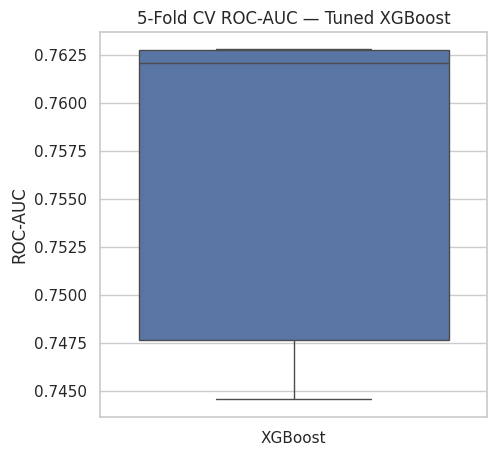

In [100]:
md("## 7b. Phase 5b — Cross-Validation (stability check)")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_xgb, X, y, cv=cv, scoring='roc_auc')

print(f"Tuned XGBoost: CV ROC-AUC = {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

plt.figure(figsize=(5, 5))
sns.boxplot(data=pd.DataFrame({'XGBoost': cv_scores}))
plt.title('5-Fold CV ROC-AUC — Tuned XGBoost')
plt.ylabel('ROC-AUC')
plt.show()

Default threshold (0.5) F1: 0.7325
Best threshold: 0.4809
Best threshold F1: 0.7515

--- Final model @ tuned threshold ---
              precision    recall  f1-score   support

           0       0.76      0.59      0.66       358
           1       0.69      0.83      0.75       388

    accuracy                           0.71       746
   macro avg       0.72      0.71      0.71       746
weighted avg       0.72      0.71      0.71       746

ROC-AUC: 0.7617635201290099
Accuracy: 0.7144772117962467


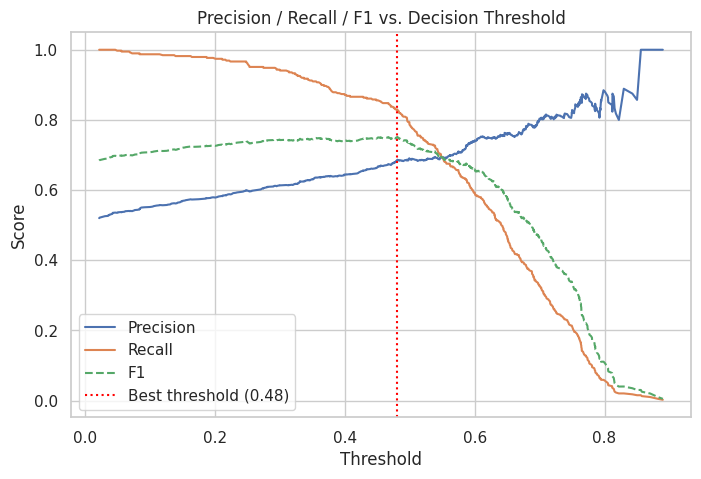

In [101]:
md("## 7c. Phase 5c — Threshold Tuning")

probs_test = best_xgb.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, probs_test)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx = np.argmax(f1_scores)

BEST_THRESHOLD = thresholds[best_idx]  # locked in as final operating threshold

print(f"Default threshold (0.5) F1: {f1_score(y_test, (probs_test >= 0.5).astype(int)):.4f}")
print(f"Best threshold: {BEST_THRESHOLD:.4f}")
print(f"Best threshold F1: {f1_scores[best_idx]:.4f}")

y_pred_final = (probs_test >= BEST_THRESHOLD).astype(int)

print("\n--- Final model @ tuned threshold ---")
print(classification_report(y_test, y_pred_final))
print("ROC-AUC:", roc_auc_score(y_test, probs_test))
print("Accuracy:", accuracy_score(y_test, y_pred_final))

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores, label='F1', linestyle='--')
plt.axvline(BEST_THRESHOLD, color='red', linestyle=':', label=f'Best threshold ({BEST_THRESHOLD:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs. Decision Threshold')
plt.legend()
plt.show()

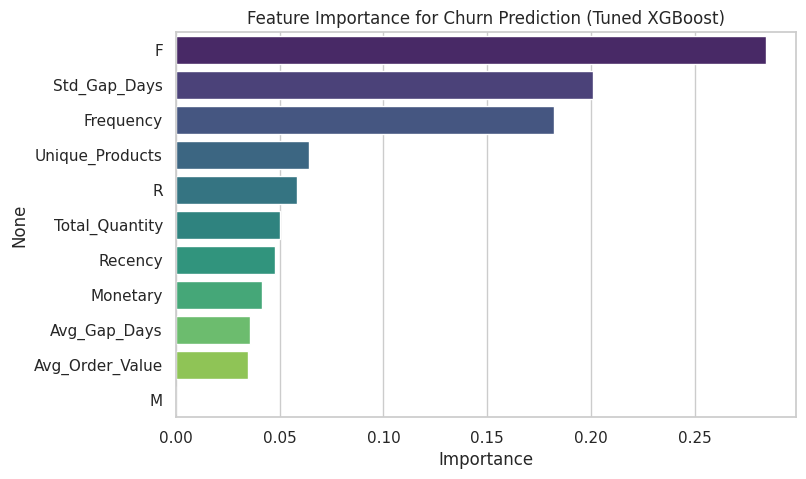

,CustomerID,Segment_Label,Churned,Churn_Probability,Churn_Predicted
0,12346,Potential Loyalist,1,0.906693,1
1,12347,Champions,0,0.295334,0
2,12348,Champions,1,0.542645,1
3,12350,Can't Lose Them,1,0.774418,1
4,12352,Champions,0,0.244215,0


In [102]:
# Feature importance - this is what lets you EXPLAIN why the model flags someone as high-risk,
# which matters more to a business stakeholder than the accuracy number itself.
md("## 7d. Feature Importance & Scoring All Customers")

importances = pd.Series(best_xgb.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance for Churn Prediction (Tuned XGBoost)')
plt.xlabel('Importance')
plt.show()

# Score every customer with probability AND the final tuned-threshold label
rfm['Churn_Probability'] = best_xgb.predict_proba(rfm[features])[:, 1]
rfm['Churn_Predicted'] = (rfm['Churn_Probability'] >= BEST_THRESHOLD).astype(int)

rfm[['CustomerID', 'Segment_Label', 'Churned', 'Churn_Probability', 'Churn_Predicted']].head()

In [103]:
md("## 8. Phase 6 — Retention Decision Matrix")

clv_median = rfm['CLV'].median()
churn_risk_median = rfm['Churn_Probability'].median()

def decision_bucket(row):
    high_value = row['CLV'] >= clv_median
    high_risk = row['Churn_Probability'] >= churn_risk_median
    if high_value and high_risk:
        return "Can't Lose - Retain Now"
    elif high_value and not high_risk:
        return "Champions - Reward & Delight"
    elif not high_value and high_risk:
        return "Let Go - Low Priority"
    else:
        return "Nurture - Low-Cost Engagement"

rfm['Action_Bucket'] = rfm.apply(decision_bucket, axis=1)
rfm['Action_Bucket'].value_counts()

,count
Action_Bucket,
Champions - Reward & Delight,1502
Let Go - Low Priority,1501
Can't Lose - Retain Now,363
Nurture - Low-Cost Engagement,362


In [104]:
md("## 9. Phase 7 — Visualizations")

# Segment distribution
seg_counts = rfm['Segment_Label'].value_counts().reset_index()
seg_counts.columns = ['Segment_Label', 'Count']

fig = px.bar(seg_counts, x='Segment_Label', y='Count',
             title='Customer Distribution by RFM Segment',
             color='Segment_Label', color_discrete_sequence=px.colors.qualitative.Pastel)
fig.show()

# Churn rate by segment - shows which segments are actually leaking customers
churn_by_segment = (rfm.groupby('Segment_Label')['Churned']
                     .mean()
                     .sort_values(ascending=False)
                     .reset_index())

fig = px.bar(churn_by_segment, x='Segment_Label', y='Churned',
             title='Churn Rate by RFM Segment',
             labels={'Churned': 'Churn Rate'},
             color='Segment_Label', color_discrete_sequence=px.colors.qualitative.Pastel)
fig.show()

# CLV distribution by segment
fig = px.box(rfm, x='Segment_Label', y='CLV', color='Segment_Label',
             title='CLV Distribution by RFM Segment',
             color_discrete_sequence=px.colors.qualitative.Pastel)
fig.show()

# Retention strategy treemap - action bucket -> RFM segment -> customer count
fig = px.treemap(rfm, path=['Action_Bucket', 'Segment_Label'],
                  title='Retention Strategy Map: Action Bucket -> RFM Segment',
                  color='Action_Bucket', color_discrete_sequence=px.colors.qualitative.Pastel)
fig.show()

# The core decision-matrix visual: CLV vs churn risk, colored by recommended action
fig = px.scatter(rfm, x='CLV', y='Churn_Probability', color='Action_Bucket',
                  hover_data=['CustomerID', 'Segment_Label'],
                  title='Retention Priority Map: CLV vs Churn Risk')
fig.add_hline(y=churn_risk_median, line_dash='dash')
fig.add_vline(x=clv_median, line_dash='dash')
fig.show()
